# Retry schedules and the herd they create

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/phoebefu6/phoebe-the-builder/blob/main/automation-suite/retry-schedule/demo.ipynb)
[![Binder](https://mybinder.org/badge_logo.svg)](https://mybinder.org/v2/gh/phoebefu6/phoebe-the-builder/main?labpath=automation-suite/retry-schedule/demo.ipynb)

A backoff function returns a delay. The delay is not the interesting thing.

The interesting thing is what happens when 500 clients fail at the *same* instant, because
that is the only time retries matter. Each of them runs the same deterministic function over
the same attempt counter and schedules its next request for the same moment. Exponential
backoff spaces those moments further and further apart, which reduces the **total** work the
dependency absorbs and does nothing at all to the **peak** - and peak is what takes the
service down a second time.

This notebook is self-contained: no imports from the repo, no API keys, no network.

**What it covers**

1. Five retry policies that are actually deployed, written from their published algorithms
2. A fleet simulator where shed load burns an attempt exactly like failed load
3. The headline run - the same 20-second outage through all five
4. The inversion: the policy with the **lowest peak** loses the **most clients**
5. Why - jitter is drawn downward, so it halves your reach
6. The cap is a load floor, not a safety valve
7. A three-panel figure and a `try your own` cell

## 1. Five policies

`full_jitter`, `equal_jitter` and `decorrelated_jitter` are written from the algorithms
published in the AWS Architecture Blog post *Exponential Backoff And Jitter* (Brooker, 2015).
`no_jitter` is the capped exponential every tutorial prints. `fixed_interval` is what a
`while True: sleep(5)` loop does, which is still the most common retry in production.

The only structural difference that matters: the first four are **ladders** - the window for
attempt *n* depends only on *n*. `decorrelated_jitter` is a **random walk** - each window is
set by the previous *draw*. That one difference changes how you have to reason about it.

In [1]:
from __future__ import annotations

import math
import random
from dataclasses import dataclass, field
from typing import Dict, List, Optional, Tuple


def no_jitter(attempt, base, cap, prev, rng):
    """min(cap, base * 2**attempt) - deterministic, so every client agrees."""
    return min(cap, base * (2.0 ** attempt))


def full_jitter(attempt, base, cap, prev, rng):
    """uniform(0, window) - lowest expected delay, therefore shortest reach."""
    return rng.uniform(0.0, min(cap, base * (2.0 ** attempt)))


def equal_jitter(attempt, base, cap, prev, rng):
    """window/2 + uniform(0, window/2) - half guaranteed, half random."""
    t = min(cap, base * (2.0 ** attempt))
    return t / 2.0 + rng.uniform(0.0, t / 2.0)


def decorrelated_jitter(attempt, base, cap, prev, rng):
    """min(cap, uniform(base, 3*prev)) - a walk. It can go DOWN, by design."""
    return min(cap, rng.uniform(base, max(base, prev * 3.0)))


def fixed_interval(attempt, base, cap, prev, rng):
    """cap, every time - the sleep(5) loop."""
    return cap


POLICIES = {"no_jitter": no_jitter, "fixed_interval": fixed_interval,
            "equal_jitter": equal_jitter, "full_jitter": full_jitter,
            "decorrelated_jitter": decorrelated_jitter}
ORDER = ["no_jitter", "fixed_interval", "equal_jitter",
         "full_jitter", "decorrelated_jitter"]

rng = random.Random(0)
print(f"{'attempt':>8}{'window':>9}   " + "".join(f"{n:>21}" for n in ORDER))
print("-" * 118)
prev = {n: 0.1 for n in ORDER}
for i in range(8):
    row = f"{i:>8}{min(20.0, 0.1 * 2 ** i):>9.2f}   "
    for n in ORDER:
        d = POLICIES[n](i, 0.1, 20.0, prev[n], random.Random(100 + i))
        prev[n] = d
        row += f"{d:>21.3f}"
    print(row)
print("-" * 118)
print("no_jitter is the same number for every client in the fleet. that is the bug.")

 attempt   window               no_jitter       fixed_interval         equal_jitter          full_jitter  decorrelated_jitter
----------------------------------------------------------------------------------------------------------------------
       0     0.10                   0.100               20.000                0.057                0.015                0.129
       1     0.20                   0.200               20.000                0.158                0.116                0.267
       2     0.40                   0.400               20.000                0.230                0.059                0.204
       3     0.80                   0.800               20.000                0.792                0.783                0.601
       4     1.60                   1.600               20.000                1.568                1.536                1.735
       5     3.20                   3.200               20.000                3.005                2.810                4.582

## 2. The fleet

The model, stated plainly so the numbers can be argued with:

* The dependency is down for `outage_s`. Every request arriving before then fails and **burns
  one attempt**.
* After recovery it serves `capacity_rps`, enforced per 100 ms bucket. Excess arrivals are
  **shed** - which is the *good* failure mode; a service without shedding falls over instead.
* **A shed request burns an attempt exactly like a failed one.** This is the step most retry
  discussions skip, and it is where herding comes from: load shed by an overloaded service is
  rescheduled by the same policy that produced the spike.
* A client that exhausts `max_attempts` gives up permanently.

One detail worth stealing: `bucket_index` below does *not* compute `int(t / width)`. With
width `0.1`, `1.5 / 0.1` evaluates to `14.999999999999998`, so an arrival sitting exactly on a
bucket edge is filed one bucket early - and on a deterministic policy the *whole fleet* sits
on that edge, so the histogram is wrong in a way that still looks plausible.

In [2]:
def bucket_index(t, width, since=0.0):
    """Half-open bucket holding t. Snapped, because i*width does not tile the line."""
    q = (t - since) / width
    i = int(math.floor(q))
    if q - i > 1.0 - 1e-9:
        i += 1
    return max(0, i)


@dataclass(frozen=True)
class Schedule:
    policy: str
    base: float = 0.1
    cap: float = 20.0
    max_attempts: int = 10

    def window(self, n):
        return self.cap if self.policy == "fixed_interval" else min(
            self.cap, self.base * (2.0 ** n))

    def delays(self, rng):
        fn, out, prev = POLICIES[self.policy], [], self.base
        for i in range(self.max_attempts):
            d = fn(i, self.base, self.cap, prev, rng)
            out.append(d)
            prev = d
        return out

    def expected_total(self, samples=4000, seed=0):
        """Exact for the ladders. Sampled for the walk - see cell 5 for why."""
        if self.policy == "decorrelated_jitter":
            r = random.Random(seed)
            return sum(sum(self.delays(r)) for _ in range(samples)) / samples
        factor = {"no_jitter": 1.0, "fixed_interval": 1.0,
                  "full_jitter": 0.5, "equal_jitter": 0.75}[self.policy]
        return factor * sum(self.window(i) for i in range(self.max_attempts))

    def steady_state_rate(self, fleet):
        """The floor: once every window hits the cap, the process stops thinning."""
        factor = {"no_jitter": 1.0, "fixed_interval": 1.0, "full_jitter": 0.5,
                  "equal_jitter": 0.75, "decorrelated_jitter": 0.5}[self.policy]
        return fleet / (self.cap * factor)


def simulate(schedule, fleet=500, outage_s=20.0, capacity_rps=50.0,
             bucket_s=0.1, seed=7, horizon_s=300.0):
    import heapq
    rng = random.Random(seed)
    streams = [random.Random(rng.randrange(1 << 30)) for _ in range(fleet)]
    prev_delay, attempt, now = [schedule.base] * fleet, [0] * fleet, [0.0] * fleet
    heap, fn = [], POLICIES[schedule.policy]

    def push(cid):
        n = attempt[cid]
        if n >= schedule.max_attempts:
            return
        d = fn(n, schedule.base, schedule.cap, prev_delay[cid], streams[cid])
        prev_delay[cid], attempt[cid] = d, n + 1
        heapq.heappush(heap, (round(now[cid] + d, 9), cid))

    for cid in range(fleet):
        push(cid)

    per_bucket = 0 if capacity_rps <= 0 else max(1, int(round(capacity_rps * bucket_s)))
    arrivals, admitted, done = [], [], [False] * fleet

    while heap and heap[0][0] <= horizon_s:
        b = bucket_index(heap[0][0], bucket_s)
        batch = []
        while heap and bucket_index(heap[0][0], bucket_s) == b:
            batch.append(heapq.heappop(heap))
        batch.sort(key=lambda e: e[1])
        served = 0
        for at, cid in batch:
            arrivals.append(at)
            now[cid] = at
            if at >= outage_s and served < per_bucket:
                served += 1
                admitted.append(at)
                done[cid] = True
            else:
                push(cid)

    return {"schedule": schedule, "arrivals": arrivals, "admitted": admitted,
            "succeeded": sum(done), "gave_up": fleet - sum(done),
            "outage_s": outage_s, "capacity_rps": capacity_rps, "fleet": fleet}


def histogram(res, width=1.0, since=0.0, upto=None):
    end = upto if upto is not None else (max(res["arrivals"]) if res["arrivals"] else since + width)
    nb = max(1, int(math.ceil((end - since) / width)))
    counts = [0] * nb
    for t in res["arrivals"]:
        if t < since:
            continue
        i = bucket_index(t, width, since)
        if i < nb:
            counts[i] += 1
    return [since + i * width for i in range(nb)], counts


def recovery_peak(res, window_s=1.0):
    _, c = histogram(res, window_s, since=res["outage_s"])
    return max(c) / window_s if c else 0.0


print("simulator ready")

simulator ready


## 3. The headline run

500 clients fail together. The dependency is down for 20 seconds, then serves 50 rps.
Base 0.1 s, cap 20 s, 10 attempts. Same seed for every policy.

In [3]:
FLEET, OUTAGE, CAPACITY = 500, 20.0, 50.0
BASE, CAP, ATTEMPTS = 0.1, 20.0, 10

sims = {n: simulate(Schedule(n, BASE, CAP, ATTEMPTS), FLEET, OUTAGE, CAPACITY, seed=7)
        for n in ORDER}

print(f"{'policy':<22}{'requests':>10}{'sent while down':>17}{'peak rps':>10}"
      f"{'recovered':>11}{'gave up':>9}{'cleared':>10}")
print("-" * 89)
for n in ORDER:
    r = sims[n]
    wasted = sum(1 for t in r["arrivals"] if t < OUTAGE)
    ct = max(r["admitted"]) if r["admitted"] else None
    cleared = f"{ct:.1f}s" if ct else "-"
    print(f"{n:<22}{len(r['arrivals']):>10}{wasted:>17}{recovery_peak(r):>10.0f}"
          f"{r['succeeded']:>11}{r['gave_up']:>9}{cleared:>10}")
print("-" * 89)
nj = sims["no_jitter"]
print(f"\nno_jitter leaves {nj['gave_up']} of {FLEET} clients PERMANENTLY failed after an")
print(f"outage the dependency itself recovered from in {OUTAGE:.0f} seconds.")
print(f"its peak on the recovering service is {recovery_peak(nj):.0f} rps against "
      f"{CAPACITY:.0f} rps of capacity.")

policy                  requests  sent while down  peak rps  recovered  gave up   cleared
-----------------------------------------------------------------------------------------
no_jitter                   4985             3500       500         15      485     65.5s
fixed_interval              4775                0       500         50      450    200.0s
equal_jitter                4388             3805        86        500        0     55.1s
full_jitter                 4679             4206        46        446       54     44.6s
decorrelated_jitter         4742             4544        25        198      302     39.5s
-----------------------------------------------------------------------------------------

no_jitter leaves 485 of 500 clients PERMANENTLY failed after an
outage the dependency itself recovered from in 20 seconds.
its peak on the recovering service is 500 rps against 50 rps of capacity.


## 4. The inversion

Now read the same table for peak and for clients lost, and notice they rank in opposite
directions.

`full_jitter` produces the gentler arrival process. `equal_jitter` produces a spike roughly
twice as tall - and loses nobody. The received advice ("use full jitter") optimises the metric
that is easy to graph.

In [4]:
print(f"{'policy':<22}{'peak rps':>10}{'clients lost':>14}")
print("-" * 46)
for n in sorted(ORDER, key=lambda k: recovery_peak(sims[k])):
    print(f"{n:<22}{recovery_peak(sims[n]):>10.0f}{sims[n]['gave_up']:>14}")
print("-" * 46)
fj, ej = sims["full_jitter"], sims["equal_jitter"]
print(f"\nfull_jitter  peak {recovery_peak(fj):>4.0f} rps -> {fj['gave_up']:>3} lost")
print(f"equal_jitter peak {recovery_peak(ej):>4.0f} rps -> {ej['gave_up']:>3} lost")
print("\nlower peak, worse outcome. peak and recovery are different objectives.")

policy                  peak rps  clients lost
----------------------------------------------
decorrelated_jitter           25           302
full_jitter                   46            54
equal_jitter                  86             0
no_jitter                    500           485
fixed_interval               500           450
----------------------------------------------

full_jitter  peak   46 rps ->  54 lost
equal_jitter peak   86 rps ->   0 lost

lower peak, worse outcome. peak and recovery are different objectives.


## 5. Why: jitter is drawn downward

`full_jitter` draws `uniform(0, window)`, so its expected delay is **half** the window. Same
ladder, same attempt count, half the wall-clock reach. A budget of 10 attempts sized against
the un-jittered schedule covers 65.5 s; add full jitter and it covers ~33 s on average.

And for `decorrelated_jitter` there is a second trap. It is a walk, so the **mean describes a
client that does not exist** - draw low early and you stay low for all ten attempts. Sizing a
budget off the expected total leaves half the fleet giving up sooner than the design doc says.

The closed form is worse than useless there. `E[d_n] = min(cap, (base + 3*E[d_{n-1}])/2)`
iterated looks obviously correct, and `min` is concave, so Jensen's inequality runs the wrong
way: `E[min(cap, X)] <= min(cap, E[X])`. Substituting the mean into the truncation
over-estimates, and the error compounds. That is why `expected_total` samples for that policy.

In [5]:
import statistics

print(f"{'policy':<22}{'worst case':>12}{'mean':>9}{'median':>9}{'p10':>8}"
      f"{'med/mean':>10}{'covers 20s?':>13}")
print("-" * 83)
for n in ORDER:
    s = Schedule(n, BASE, CAP, ATTEMPTS)
    r = random.Random(11)
    tot = sorted(sum(s.delays(r)) for _ in range(5000))
    mean, med = statistics.fmean(tot), tot[len(tot) // 2]
    worst = sum(s.window(i) for i in range(ATTEMPTS)) if n != "decorrelated_jitter" else 132.0
    covers = "yes" if med >= OUTAGE else "NO"
    print(f"{n:<22}{worst:>12.1f}{mean:>9.1f}{med:>9.1f}{tot[len(tot)//10]:>8.1f}"
          f"{med/mean:>9.0%}{covers:>13}")
print("-" * 83)

print("\nand the tempting closed form for the walk, against the truth:\n")
print(f"{'cap (s)':>9}{'naive recurrence':>19}{'sampled mean':>15}{'overstated by':>16}")
print("-" * 59)
for cap in (5.0, 20.0, 60.0):
    s = Schedule("decorrelated_jitter", BASE, cap, ATTEMPTS)
    naive, prev = 0.0, BASE
    for _ in range(ATTEMPTS):
        e = min(cap, (BASE + 3.0 * prev) / 2.0)
        naive += e
        prev = e
    true = s.expected_total()
    print(f"{cap:>9.0f}{naive:>19.1f}{true:>15.1f}{naive/true - 1:>15.0%}")
print("-" * 59)
print("the cap is what breaks it, and the cap is the part everyone adds.")

policy                  worst case     mean   median     p10  med/mean  covers 20s?
-----------------------------------------------------------------------------------
no_jitter                     65.5     65.5     65.5    65.5     100%          yes
fixed_interval               200.0    200.0    200.0   200.0     100%          yes
equal_jitter                  65.5     49.1     49.0    42.9     100%          yes
full_jitter                   65.5     32.7     32.5    20.3     100%          yes
decorrelated_jitter          132.0     23.1     13.2     4.0      57%           NO
-----------------------------------------------------------------------------------

and the tempting closed form for the walk, against the truth:

  cap (s)   naive recurrence   sampled mean   overstated by
-----------------------------------------------------------
        5               24.0           14.2            69%
       20               33.0           23.3            42%
       60               33.0   

## 6. The cap is a load floor

This is the part that has no fix at the policy level.

Once `base * 2**n` reaches the cap, the jitter window **stops widening**, so the arrival
process **stops thinning**. Each client settles into firing every `cap * factor` seconds
forever, and `fleet` clients doing that is an aggregate rate of `fleet / (cap * factor)`.

It does not decay. Jitter decides whether that load arrives as a spike or a hum; it does not
change the height. The only term you can move is the numerator - which is what a client-side
retry budget (gRPC's `retryThrottling`, a token bucket that only refills on success) actually
does.

In [6]:
print(f"{'cap (s)':>9}{'predicted floor':>18}{'measured rps':>15}{'vs 50 rps capacity':>21}")
print("-" * 63)
for cap in (5.0, 10.0, 20.0, 30.0, 60.0):
    s = Schedule("full_jitter", BASE, cap, max_attempts=80)
    r = simulate(s, FLEET, OUTAGE, capacity_rps=0.0, seed=3, horizon_s=6 * cap + 200)
    lo, hi = 3 * cap, 5 * cap
    measured = sum(1 for t in r["arrivals"] if lo <= t < hi) / (hi - lo)
    pred = s.steady_state_rate(FLEET)
    flag = "OVER" if pred > CAPACITY else "ok"
    print(f"{cap:>9.0f}{pred:>18.0f}{measured:>15.0f}{flag:>21}")
print("-" * 63)
print("(capacity 0 so nothing is admitted - this isolates the arrival process.)")
print("\nfloor = fleet / (cap/2) = 1000/cap rps. a 20s cap on a 500-client fleet is")
print("50 rps of steady load, which is the entire capacity, forever.")

print("\nnested retries multiply - the other term nobody owns:")
for label, layers in [("browser 3", [3]), ("+ gateway 3", [3, 3]),
                      ("+ service 3", [3, 3, 3]), ("+ db driver 2", [3, 3, 3, 2])]:
    amp = 1
    for a in layers:
        amp *= a
    print(f"  {label:<16} {amp:>4}x at the bottom service")

  cap (s)   predicted floor   measured rps   vs 50 rps capacity
---------------------------------------------------------------
        5               200            201                 OVER
       10               100            100                 OVER
       20                50             51                   ok
       30                33             34                   ok
       60                17             17                   ok
---------------------------------------------------------------
(capacity 0 so nothing is admitted - this isolates the arrival process.)

floor = fleet / (cap/2) = 1000/cap rps. a 20s cap on a 500-client fleet is
50 rps of steady load, which is the entire capacity, forever.

nested retries multiply - the other term nobody owns:
  browser 3           3x at the bottom service
  + gateway 3         9x at the bottom service
  + service 3        27x at the bottom service
  + db driver 2      54x at the bottom service


## 7. The picture

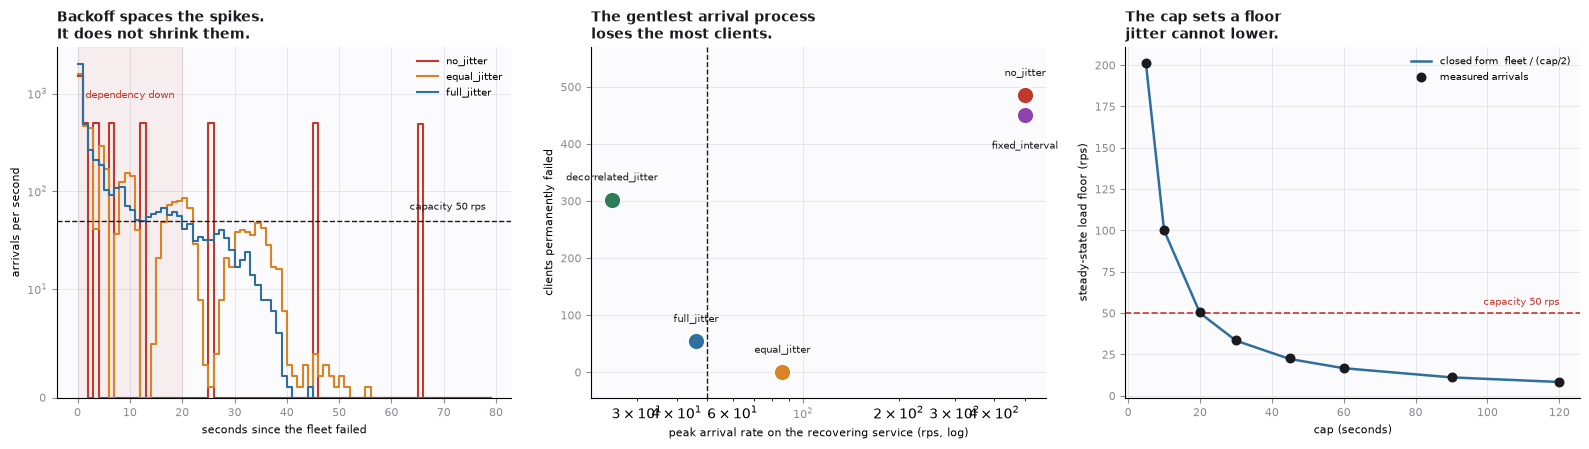

In [7]:
import matplotlib.pyplot as plt

INK, MUTED, GRID = "#1b1b1f", "#8a8a94", "#e3e3e8"
BAD, WARN, COOL, OK = "#c0392b", "#d98324", "#2f6f9f", "#2d7d5a"
COLOR = {"no_jitter": BAD, "fixed_interval": "#8e44ad", "equal_jitter": WARN,
         "full_jitter": COOL, "decorrelated_jitter": OK}

fig, axes = plt.subplots(1, 3, figsize=(16, 4.6))
fig.patch.set_facecolor("white")

ax = axes[0]
for n in ("no_jitter", "equal_jitter", "full_jitter"):
    e, c = histogram(sims[n], 1.0, 0.0, upto=80.0)
    ax.plot(e, c, color=COLOR[n], lw=1.5, label=n, drawstyle="steps-post")
ax.axvspan(0, OUTAGE, color=BAD, alpha=0.07)
ax.axhline(CAPACITY, color=INK, ls="--", lw=1.0)
ax.text(78, CAPACITY * 1.3, "capacity 50 rps", fontsize=7.5, ha="right", color=INK)
ax.text(OUTAGE / 2, 900, "dependency down", color=BAD, fontsize=7.5, ha="center")
ax.set_yscale("symlog", linthresh=10)
ax.set_ylim(0, 3000)
ax.set_xlabel("seconds since the fleet failed", fontsize=8)
ax.set_ylabel("arrivals per second", fontsize=8)
ax.legend(frameon=False, fontsize=7.5)
ax.set_title("Backoff spaces the spikes.\nIt does not shrink them.",
             fontsize=10, weight="bold", loc="left", color=INK)

ax = axes[1]
for n in ORDER:
    ax.scatter([recovery_peak(sims[n])], [sims[n]["gave_up"]], s=150,
               color=COLOR[n], edgecolor="white", lw=1.3, zorder=3)
    dy = -24 if n == "fixed_interval" else 14
    ax.annotate(n, (recovery_peak(sims[n]), sims[n]["gave_up"]),
                textcoords="offset points", xytext=(0, dy), ha="center",
                fontsize=7.2, color=INK)
ax.axvline(CAPACITY, color=INK, ls="--", lw=1.0)
ax.set_xscale("log")
ax.set_ylim(-45, 570)
ax.set_xlabel("peak arrival rate on the recovering service (rps, log)", fontsize=8)
ax.set_ylabel("clients permanently failed", fontsize=8)
ax.set_title("The gentlest arrival process\nloses the most clients.",
             fontsize=10, weight="bold", loc="left", color=INK)

ax = axes[2]
caps = [5.0, 10.0, 20.0, 30.0, 45.0, 60.0, 90.0, 120.0]
pred = [Schedule("full_jitter", BASE, c, ATTEMPTS).steady_state_rate(FLEET) for c in caps]
meas = []
for c in caps:
    s = Schedule("full_jitter", BASE, c, max_attempts=80)
    r = simulate(s, FLEET, OUTAGE, capacity_rps=0.0, seed=3, horizon_s=6 * c + 200)
    lo, hi = 3 * c, 5 * c
    meas.append(sum(1 for t in r["arrivals"] if lo <= t < hi) / (hi - lo))
ax.plot(caps, pred, color=COOL, lw=1.8, label="closed form  fleet / (cap/2)")
ax.scatter(caps, meas, s=38, color=INK, zorder=3, label="measured arrivals")
ax.axhline(CAPACITY, color=BAD, ls="--", lw=1.2)
ax.text(120, CAPACITY * 1.1, "capacity 50 rps", color=BAD, fontsize=7.5, ha="right")
ax.set_xlabel("cap (seconds)", fontsize=8)
ax.set_ylabel("steady-state load floor (rps)", fontsize=8)
ax.legend(frameon=False, fontsize=7.5)
ax.set_title("The cap sets a floor\njitter cannot lower.",
             fontsize=10, weight="bold", loc="left", color=INK)

for ax in axes:
    ax.set_facecolor("#fbfbfd")
    ax.grid(True, color=GRID, lw=0.6)
    ax.set_axisbelow(True)
    ax.tick_params(colors=MUTED, labelsize=8)
    for sp in ("top", "right"):
        ax.spines[sp].set_visible(False)

fig.tight_layout()
fig.savefig("retry_demo.png", dpi=150, facecolor="white")
plt.show()

## Summary

| What people believe | What the simulation shows |
|---|---|
| Exponential backoff prevents thundering herds | It spaces the spikes. Every spike is still the full fleet - here 500 arrivals in one 100 ms bucket, 10x capacity. |
| Jitter is the fix | Jitter fixes the *shape*. The *volume* is `fleet/cap` and jitter does not appear in that expression. |
| Full jitter is the best option | It has the lowest peak (46 rps) and loses 54 clients. `equal_jitter` peaks at 86 rps and loses none. |
| More attempts means more coverage | Full jitter halves the expected reach at the same attempt count: 65.5 s becomes ~33 s. |
| A cap makes backoff safe | A cap makes the arrival process stop thinning. It is a load *floor* of `2N/cap` rps that never decays. |
| The mean tells you the budget | For the decorrelated walk the median client covers 13 s against a 23 s mean, and the tempting closed form overstates even the mean by 42%. |
| Retries are a client concern | They multiply across layers. Three reasonable layers of three attempts is 27x at the bottom service. |

**What actually helps**

- Cap the *fleet*, not just the delay - a client-side retry budget (gRPC `retryThrottling`, a
  token bucket that only refills on success) reduces the only term that matters.
- Retry at **one** layer. Amplification is a product; make every other layer pass the error
  through.
- Size the budget against the **median**, and against the outage you actually need to outlast.
- Check the jitter survives your scheduler: a window narrower than the timer tick is quantised
  away and the fleet re-synchronises.

## Try your own

Uncomment and edit. The interesting knob is `fleet` - it is the only term in the floor you
can move.

In [8]:
# --- your fleet -------------------------------------------------------------
# MY_FLEET     = 2000     # how many clients fail together
# MY_OUTAGE    = 45.0     # seconds the dependency is down
# MY_CAPACITY  = 200.0    # rps once it is back
# MY_BASE      = 0.5      # first retry delay
# MY_CAP       = 30.0     # ceiling
# MY_ATTEMPTS  = 6
#
# for n in ORDER:
#     s = Schedule(n, MY_BASE, MY_CAP, MY_ATTEMPTS)
#     r = simulate(s, MY_FLEET, MY_OUTAGE, MY_CAPACITY, seed=7)
#     print(f"{n:<22} peak {recovery_peak(r):>6.0f} rps   "
#           f"recovered {r['succeeded']:>5}   lost {r['gave_up']:>5}   "
#           f"floor {s.steady_state_rate(MY_FLEET):>6.0f} rps")
#
# print("\nif the floor is above your capacity, no policy in this notebook helps.")
# print("the fix is fewer clients retrying, not a different random distribution.")

---

**Day 145** of the [phoebe-the-builder](https://github.com/phoebefu6/phoebe-the-builder) portfolio -
[`automation-suite/retry-schedule`](https://github.com/phoebefu6/phoebe-the-builder/tree/main/automation-suite/retry-schedule).

The repo version adds an audit engine (10 finding types across three severities, three
verdicts), 57 tests including an integer-arithmetic cross-check of the bucketing that found
two real bugs in this code, and a Streamlit app:

```bash
pip install -r requirements.txt
streamlit run app.py
```

Sources for the policies: AWS Architecture Blog, *Exponential Backoff And Jitter*
(Marc Brooker, 2015); gRPC `retryThrottling` in the service-config spec.